<a href="https://colab.research.google.com/github/tsopronyuk/dfa-lexical-analyzer/blob/main/notebooks/03_table_driven_dfa_lexer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import graphviz

class UniversalDFA:
    """
    A 100% generic Deterministic Finite Automaton (DFA) engine.
    State representation rules:
      - Initial state: 0 (gold double circle)
      - Intermediate states: 1, 2, 3... (circles)
      - Final states: Negative integers (-1, -2...) with type descriptions.
    """
    def __init__(self, config):
        self.name = config.get("name", "Universal DFA Engine")
        self.matrix = config["matrix"]
        self.char_classes = config["char_classes"]
        self.default_class = config["default_class"]

        self.final_states = {
            int(k): v for k, v in config["final_states"].items()
        }
        self.skip_state_id = min(self.final_states.keys())
        self.backtrack_rules = config.get("backtrack_rules", {})

    def _get_char_class(self, char):
        """Maps an input character to its corresponding character class index."""
        for char_set, cls_idx in self.char_classes.items():
            if char_set == "isalpha_or_underscore":
                if char.isalpha() or char == '_':
                    return cls_idx
            elif char in char_set:
                return cls_idx
        return self.default_class

    def tokenize(self, text):
        """Performs lexical analysis using lookahead logic."""
        tokens = []
        text_buffer = text + '\0'
        start = i = state = 0

        while start < len(text_buffer) - 1:
            c = text_buffer[i]
            cl = self._get_char_class(c)
            next_state = self.matrix[state][cl]

            if next_state < 0:
                if next_state == self.skip_state_id:
                    start += 1
                    i = start
                    state = 0
                elif str(next_state) in self.backtrack_rules and state in self.backtrack_rules[str(next_state)]["from_states"]:
                    rule = self.backtrack_rules[str(next_state)]
                    tokens.append({
                        "type": self.final_states[rule["emit_type_id"]]["name"],
                        "value": rule["emit_value"]
                    })
                    start += rule.get("step", 1)
                    i = start
                    state = 0
                else:
                    val = text_buffer[start:i]
                    token_info = self.final_states.get(next_state, {"name": "Unknown"})
                    tokens.append({"type": token_info["name"], "value": val})
                    start = i
                    state = 0
            else:
                state = next_state
                i += 1

        return tokens

    def _format_label(self, raw_key):
        """Formats character ranges into compact strings."""
        if raw_key == "isalpha_or_underscore":
            return "a-z, _"
        elif raw_key.isdigit() and len(raw_key) > 3:
            return f"{raw_key[0]}..{raw_key[-1]}"
        elif raw_key.isalpha() and len(raw_key) > 4:
            return f"{raw_key[0]}..{raw_key[-1]}"
        return raw_key

    def render_graph(self, hide_noise=True):
        """
        Renders Graphviz DFA diagram matching exact article semantics:
        - Labels fallback and default branches strictly as 'else'.
        - Dashed lines for terminal transitions and prefix backtracking.
        """
        dot = graphviz.Digraph(
            comment=self.name,
            graph_attr={
                'rankdir': 'LR',
                'nodesep': '0.15',
                'ranksep': '0.35',
                'margin': '0.02'
            },
            node_attr={
                'fontsize': '9',
                'height': '0.25',
                'width': '0.25',
                'margin': '0.03'
            },
            edge_attr={
                'fontsize': '8',
                'arrowsize': '0.6'
            }
        )

        # 1. Map class indices to human-readable strings
        class_to_label = {}
        for char_set, cls_idx in self.char_classes.items():
            formatted = self._format_label(str(char_set))
            if cls_idx not in class_to_label:
                class_to_label[cls_idx] = []
            class_to_label[cls_idx].append(formatted)

        # 2. Add Initial State 0
        dot.node('0', '0', shape='doublecircle', fillcolor='gold', style='filled')

        # 3. Add Final States (negative numbers)
        for st_id, info in self.final_states.items():
            if hide_noise and st_id == self.skip_state_id:
                continue
            dot.node(f"{st_id}", f"{st_id}\n({info['name']})",
                     shape='box', style='filled', fillcolor=info.get('color', 'white'))

        # 4. Add Intermediate States (1, 2, 3...)
        num_states = len(self.matrix)
        for s in range(1, num_states):
            dot.node(f"{s}", f"{s}", shape='circle')

        # 5. Process transitions and assign 'else' labels
        for s_from in range(num_states):
            from_node = str(s_from)

            # Map target state -> list of character class indices
            target_map = {}
            for cls_idx, s_to in enumerate(self.matrix[s_from]):
                if hide_noise and s_to == self.skip_state_id:
                    continue
                if s_to not in target_map:
                    target_map[s_to] = []
                target_map[s_to].append(cls_idx)

            if not target_map:
                continue

            # Identify fallback target state to label as 'else'
            else_target = None
            if len(target_map) == 1:
                (s_to, cls_list), = target_map.items()
                if len(cls_list) > 1 or self.default_class in cls_list:
                    else_target = s_to
            else:
                max_classes = -1
                for s_to, cls_list in target_map.items():
                    if self.default_class in cls_list:
                        else_target = s_to
                        break
                    elif len(cls_list) > max_classes:
                        max_classes = len(cls_list)
                        else_target = s_to

            # Draw edges
            for s_to, cls_list in target_map.items():
                to_node = str(s_to)

                if s_to == else_target:
                    label_str = "else"
                else:
                    labels = []
                    for c_idx in cls_list:
                        labels.extend(class_to_label.get(c_idx, []))
                    label_str = ", ".join(labels) if labels else "else"

                is_terminal = (s_to < 0)
                is_backtrack = (str(s_to) in self.backtrack_rules and
                                s_from in self.backtrack_rules[str(s_to)]["from_states"])

                if is_backtrack:
                    dot.edge(from_node, to_node, label=f" {label_str} ", style='dashed', color='darkorange', fontcolor='darkorange')
                elif is_terminal:
                    dot.edge(from_node, to_node, label=f" {label_str} ", style='dashed', color='gray30', fontcolor='gray20')
                else:
                    dot.edge(from_node, to_node, label=f" {label_str} ")

        return dot

print("✅ Engine updated: Fallback branches correctly marked as 'else'.")

✅ Engine updated: Fallback branches correctly marked as 'else'.


In [ ]:
# ============================================================================
# CONFIGURATION 1: Keywords and Numbers DFA (WITH BACKTRACKING RULES)
# Tokens: Keywords (go, goon, open, online), Numbers (0-9+), Noise (-6)
# ============================================================================
DFA_CONFIG_KEYWORDS = {
    "name": "Keywords and Numbers DFA",
    "char_classes": {
        "0123456789": 0,
        "g": 1,
        "o": 2,
        "p": 3,
        "e": 4,
        "n": 5,
        "l": 6,
        "i": 7
    },
    "default_class": 8,
    "matrix": [
        #  0   1   2   3   4   5   6   7   8
        [  1,  2,  5, -6, -6, -6, -6, -6, -6 ], # 0: Start
        [  1, -5, -5, -5, -5, -5, -5, -5, -5 ], # 1: Accumulate number [0-9]+
        [ -6, -6,  3, -6, -6, -6, -6, -6, -6 ], # 2: 'g'
        [ -1, -1,  4, -1, -1, -1, -1, -1, -1 ], # 3: 'go' (else -> -1)
        [ -1, -1, -1, -1, -1, 10, -1, -1, -1 ], # 4: 'goo' (else -> -1)
        [ -6, -6, -6,  6, -6,  8, -6, -6, -6 ], # 5: 'o'
        [ -6, -6, -6, -6,  7, -6, -6, -6, -6 ], # 6: 'op'
        [ -6, -6, -6, -6, -6, 11, -6, -6, -6 ], # 7: 'ope'
        [ -6, -6, -6, -6, -6, -6,  9, -6, -6 ], # 8: 'on'
        [ -6, -6, -6, -6, -6, -6, -6, 12, -6 ], # 9: 'onl'
        [ -2, -2, -2, -2, -2, -2, -2, -2, -2 ], # 10: Final 'goon' (-2)
        [ -3, -3, -3, -3, -3, -3, -3, -3, -3 ], # 11: Final 'open' (-3)
        [ -6, -6, -6, -6, -6, 13, -6, -6, -6 ], # 12: 'onli'
        [ -6, -6, -6, -6, 14, -6, -6, -6, -6 ], # 13: 'onlin'
        [ -4, -4, -4, -4, -4, -4, -4, -4, -4 ]  # 14: Final 'online' (-4)
    ],
    "final_states": {
        -1: {"name": "Keyword (go)", "color": "lightgreen"},
        -2: {"name": "Keyword (goon)", "color": "mediumseagreen"},
        -3: {"name": "Keyword (open)", "color": "lightblue"},
        -4: {"name": "Keyword (online)", "color": "skyblue"},
        -5: {"name": "Number", "color": "khaki"},
        -6: {"name": "Skip (Noise)", "color": "gainsboro"}
    },
    # Explicitly specify fallback/backtrack transitions from states 3 and 4 to state -1
    "backtrack_rules": {
        "-1": {
            "from_states": [3, 4],
            "emit_type_id": -1,
            "emit_value": "go"
        }
    }
}

In [ ]:
# ============================================================================
# CONFIGURATION 2: Numeric Constants and Identifiers (with Backtracking)
# ============================================================================
DFA_CONFIG_NUMBERS = {
    "name": "Numeric Constants & Identifiers DFA",
    "char_classes": {
        "0": 0, "1": 1, "234567": 2, "89": 3,
        "bB": 4, "xX": 5, "oO": 6, "abcdefABCDEF": 7,
        "isalpha_or_underscore": 8
    },
    "default_class": 9,
    "matrix": [
        [  1,  2,  2,  2,  3,  3,  3,  3,  3, -6 ], # State 0
        [  2,  2,  2,  2,  4,  5,  6, -3, -3, -3 ], # State 1
        [  2,  2,  2,  2, -3, -3, -3, -3, -3, -3 ], # State 2
        [  3,  3,  3,  3,  3,  3,  3,  3,  3, -1 ], # State 3
        [  7,  7, -3, -3, -3, -3, -3, -3, -3, -3 ], # State 4
        [  8,  8,  8,  8,  8, -3, -3,  8, -3, -3 ], # State 5
        [  9,  9,  9, -3, -3, -3, -3, -3, -3, -3 ], # State 6
        [  7,  7, -2, -2, -2, -2, -2, -2, -2, -2 ], # State 7
        [  8,  8,  8,  8,  8, -5, -5,  8, -5, -5 ], # State 8
        [  9,  9,  9, -4, -4, -4, -4, -4, -4, -4 ]  # State 9
    ],
    "final_states": {
        -1: {"name": "Identifier", "color": "lightblue"},
        -2: {"name": "Binary Constant", "color": "lightgreen"},
        -3: {"name": "Decimal Constant", "color": "khaki"},
        -4: {"name": "Octal Constant", "color": "lightpink"},
        -5: {"name": "Hexadecimal Constant", "color": "plum"},
        -6: {"name": "Skip (Noise)", "color": "gainsboro"}
    },
    "backtrack_rules": {
        "-3": {
            "from_states": [4, 5, 6],
            "emit_type_id": -3,
            "emit_value": "0",
            "step": 1
        }
    }
}

print("✅ Configurations loaded successfully.")

✅ Configurations loaded successfully.


================ TEST 1: KEYWORDS & NUMBERS ================
Value: goon            | Type: Keyword (goon)
Value: 12345           | Type: Number
Value: go              | Type: Keyword (go)
Value: open            | Type: Keyword (open)
Value: online          | Type: Keyword (online)


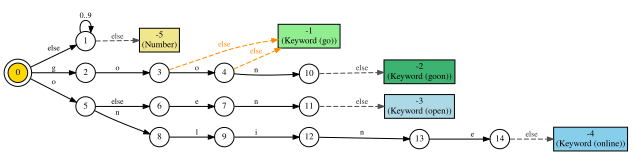

In [ ]:
# Test 1: Keywords Analyzer
print("================ TEST 1: KEYWORDS & NUMBERS ================")
engine_1 = UniversalDFA(DFA_CONFIG_KEYWORDS)
input_text_1 = "goon 12345 go open online"

tokens_1 = engine_1.tokenize(input_text_1)
for t in tokens_1:
    print(f"Value: {t['value']:<15} | Type: {t['type']}")

engine_1.render_graph(hide_noise=True)


========== TEST 2: NUMERIC CONSTANTS & IDENTIFIERS ==========
Value: 0b1010          | Type: Binary Constant
Value: var_1           | Type: Identifier
Value: 0x1A3F          | Type: Hexadecimal Constant
Value: 0o755           | Type: Octal Constant
Value: 12345           | Type: Decimal Constant
Value: 0               | Type: Decimal Constant
Value: b2_test         | Type: Identifier


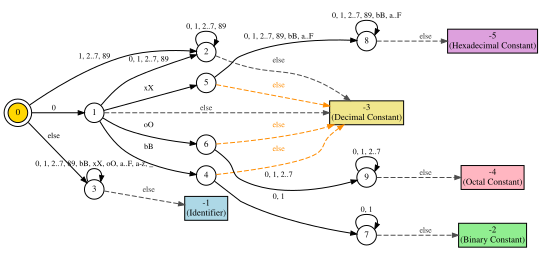

In [ ]:
# Test 2: Numeric Constants & Identifiers (Backtracking)
print("\n========== TEST 2: NUMERIC CONSTANTS & IDENTIFIERS ==========")
engine_2 = UniversalDFA(DFA_CONFIG_NUMBERS)
input_text_2 = "0b1010 var_1 0x1A3F 0o755 12345 0b2_test"

tokens_2 = engine_2.tokenize(input_text_2)
for t in tokens_2:
    print(f"Value: {t['value']:<15} | Type: {t['type']}")

engine_2.render_graph(hide_noise=True)